# 04 · The Universal DataProduct — one container, every probe

Cosmology uses many probes with very different data: point catalogues (clustering, peculiar velocities, supernovae), sheared galaxy shapes with photometric-redshift PDFs (weak lensing), absorption spectra along lines of sight (Lyα forest), and pixelised fields (CMB lensing, tSZ, HI). `oneuniverse.measure` represents **all** of them with one container — a *DataProduct* in three geometry flavours (point set, sightline, field map) — and one cosmology-free output object, the `MeasurementSet`.

**Claim.** A single, consistent interface produces analysis-ready measurements for every major probe, and the container can also express probes that do not yet have a one-call builder (clusters, strong-lens time delays, gravitational-wave sirens, line-intensity mapping).

In [1]:
%matplotlib inline
import os, sys, time, tempfile, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, healpy as hp
plt.rcParams.update({'figure.dpi':110,'font.size':11})
ROOT = Path.cwd().parent; sys.path.insert(0, str(ROOT/'test'))
TMP = Path(tempfile.mkdtemp())
DATA_ROOT='/home/ravoux/Documents/Science/Cosmography/oneuniverse_data'
EBOSS=Path(DATA_ROOT)/'spectroscopic/eboss/qso/DR16Q_Superset_v3.fits'
DESI =Path(DATA_ROOT)/'spectroscopic/desi/dr1/qso/QSO_full.dat.fits'
HAVE_EBOSS, HAVE_DESI = EBOSS.exists(), DESI.exists()
from oneuniverse.simulation.cosmology import CosmologySpec
COSMO = CosmologySpec(omega_m=0.31, omega_b=0.048, h=0.67, n_s=0.96, sigma8=0.81, t_cmb=2.7255)
print('real data — eBOSS:',HAVE_EBOSS,'| DESI:',HAVE_DESI)
def eboss_or_synth_view(tmp, n_cap=40000):
    from fixtures.measure_ouf import synthetic_point_view
    from oneuniverse.data.converter import write_ouf_dataset
    from oneuniverse.data.dataset_view import DatasetView
    from oneuniverse.data.format_spec import DataGeometry
    from oneuniverse.data.manifest import LoaderSpec
    if not HAVE_EBOSS:
        return synthetic_point_view(tmp, n=n_cap, seed=1, name='synth'), False
    os.environ['ONEUNIVERSE_DATA_ROOT']=DATA_ROOT
    from oneuniverse.data import load_catalog
    df=load_catalog('eboss_qso',validate=False)
    df=df[(df['z']>=0.8)&(df['z']<=2.2)].dropna(subset=['ra','dec','z'])
    if len(df)>n_cap: df=df.sample(n_cap,random_state=0)
    df=df.reset_index(drop=True); n=len(df); ra=df['ra'].to_numpy(float); dec=df['dec'].to_numpy(float)
    out=pd.DataFrame({'ra':ra,'dec':dec,'z':df['z'].to_numpy(float),'z_type':np.full(n,'spec'),
        'z_err':np.full(n,1e-4),'galaxy_id':np.arange(n,dtype=np.int64),'survey_id':np.zeros(n,dtype=np.int64),
        'weight_comp':np.ones(n),'nbar':np.full(n,1e-3),'_original_row_index':np.arange(n,dtype='i8'),
        '_healpix32':hp.ang2pix(32,ra,dec,nest=True,lonlat=True).astype('i4')})
    od=tmp/'eboss'/'oneuniverse'
    write_ouf_dataset(df=out,out_dir=od,survey_name='eboss',survey_type='spectroscopic',geometry=DataGeometry.POINT,loader=LoaderSpec(name='eboss',version='0'))
    return DatasetView.from_path(od.parent), True
from oneuniverse import measure
from oneuniverse.combine.weights import FKPWeight, ColumnWeight
from fixtures.measure_ouf import (synthetic_shear_view, synthetic_pv_view,
    synthetic_sn_view, synthetic_sightline_view, synthetic_healpix_map, synthetic_point_view)
from oneuniverse.measure.fieldmap import fieldmap_from_healpix

/home/ravoux/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


real data — eBOSS: True | DESI: True


## Galaxy clustering (real eBOSS) and weak lensing (tomographic n(z))

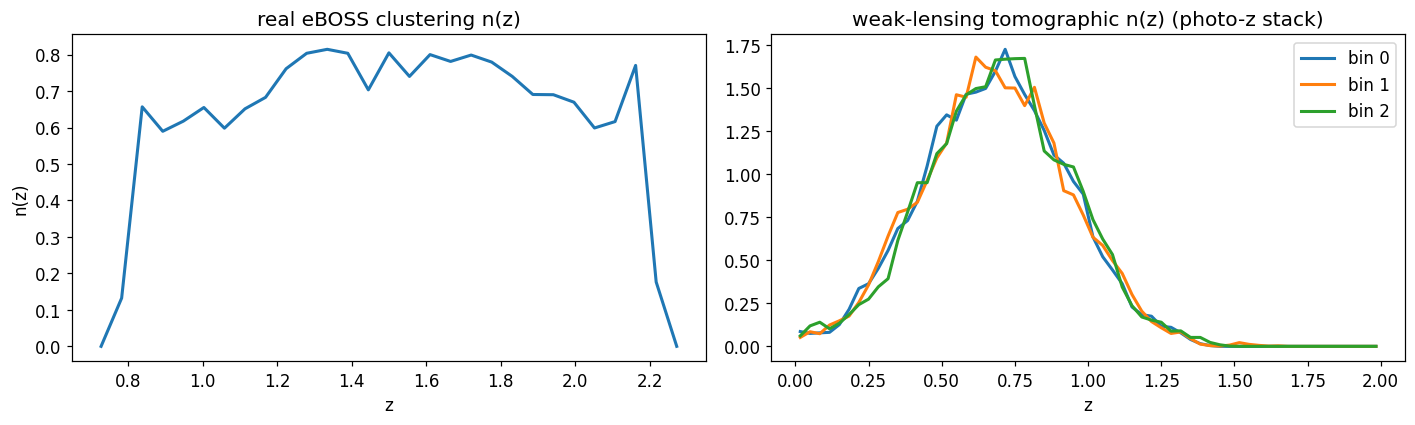

shear shapes carried: ['e1', 'e2', 'e1_err', 'e2_err', 'R11', 'R22', 'R_S', 'm_bias', 'c1_bias', 'c2_bias', 'shear_weight']


In [2]:
view,real=eboss_or_synth_view(TMP,n_cap=30000)
clu=measure.build_galaxy_clustering(view,tracer='qso',z_range=(0.8,2.2),
    weights=[FKPWeight(nbar=lambda z: np.full_like(z,1e-3),P0=1e4)],nside_window=64,nside_region=16,
    nz_edges=np.linspace(0.7,2.3,30),randoms='generate',n_randoms=3*view.n_rows,seed=1)
sv=synthetic_shear_view(TMP,n=6000,seed=3,kind='metacal',with_pdf=True,n_tomo=3,name='src')
wl=measure.build_cosmic_shear(sv,z_grid=np.linspace(0,2,61),nside_region=8)
fig,ax=plt.subplots(1,2,figsize=(13,4))
cp=clu.products['qso']; ax[0].plot(cp.nz.centers(),cp.nz.pdf(),lw=2)
ax[0].set_title(('real eBOSS' if real else 'synthetic')+' clustering n(z)'); ax[0].set_xlabel('z'); ax[0].set_ylabel('n(z)')
for bidx,nz in sorted(wl.products['src'].nz.items()): ax[1].plot(nz.centers(),nz.pdf(),lw=2,label=f'bin {bidx}')
ax[1].set_title('weak-lensing tomographic n(z) (photo-z stack)'); ax[1].set_xlabel('z'); ax[1].legend(); plt.tight_layout(); plt.show()
print('shear shapes carried:', wl.products['src'].attributes['shapes'])

## Peculiar velocities, supernovae, Lyα sightlines, map×catalog

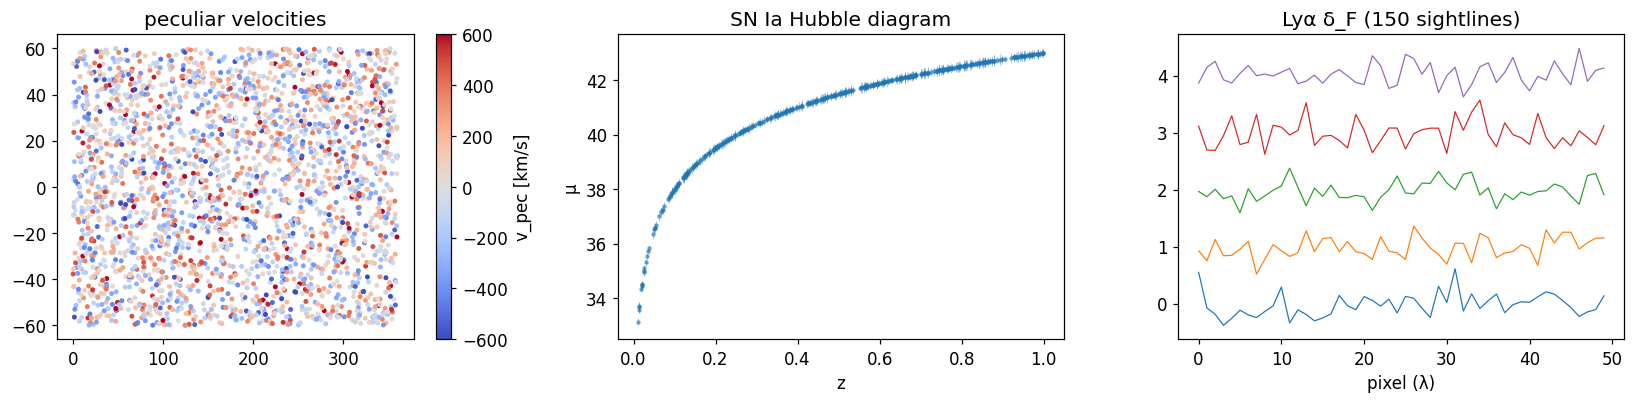

In [3]:
pv=measure.build_peculiar_velocity(synthetic_pv_view(TMP,n=2500,seed=3,name='pv'),z_range=(0,0.1),nside_region=8)
snv,_=synthetic_sn_view(TMP,n=400,seed=4,name='sn'); sn=measure.build_sn_hubble(snv,nside_region=4)
lya=measure.build_lya(synthetic_sightline_view(TMP,n_los=150,n_pix=50,seed=2,name='lya'),nside_region=8)
vals,mask=synthetic_healpix_map(nside=64,seed=4); fm=fieldmap_from_healpix(vals,mask=mask,nside=64,dataset_id='cmbk')
xc=measure.build_map_cross(synthetic_point_view(TMP,n=5000,seed=3,name='g2'),fm,nside_region=8,z_range=(0.1,1.0))
fig,ax=plt.subplots(1,3,figsize=(15,3.8))
pc=pv.products['pv'].catalog; s0=ax[0].scatter(pc['ra'],pc['dec'],s=5,c=pc['v_pec'],cmap='coolwarm',vmin=-600,vmax=600)
ax[0].set_title('peculiar velocities'); plt.colorbar(s0,ax=ax[0],label='v_pec [km/s]')
sc=sn.products['sn'].catalog; ax[1].errorbar(sc['z'],sc['mu'],yerr=sc['mu_err'],fmt='.',ms=4,alpha=.5,elinewidth=.5); ax[1].set_title('SN Ia Hubble diagram'); ax[1].set_xlabel('z'); ax[1].set_ylabel('μ')
sl=lya.products['lya']
for i in range(5): ax[2].plot(sl.delta[i]+i*1.0,lw=.8)
ax[2].set_title(f'Lyα δ_F ({sl.n_sightlines} sightlines)'); ax[2].set_xlabel('pixel (λ)'); plt.tight_layout(); plt.show()

## Every probe → one cosmology-free contract
And the container expresses builder-less probes via optional atom slots (sub-object links, named/PIP weights, covariance plans, beam/interloper metadata).

In [4]:
rows=[('galaxy clustering',clu),('weak lensing',wl),('peculiar velocity',pv),('supernovae',sn),('Lyα forest',lya),('galaxy×CMBκ',xc)]
print(f"{'probe':20s} {'family':12s} {'statistic':16s} subtype(s)")
for nm,m in rows:
    s=m.summary(); kinds=','.join(sorted({p['kind'] for p in s['products'].values()}))
    print(f"{nm:20s} {s['spec']['estimator_family']:12s} {s['spec']['statistic']:16s} {kinds}")
print('\nbuilder-less probes covered by the container (test_measure_generality.py):')
print('  clusters · strong-lens time delays · radio (z-absent) · GW sirens · line-intensity mapping')

probe                family       statistic        subtype(s)
galaxy clustering    clustering   pk_multipole     pointset
weak lensing         lensing      xi_pm            pointset
peculiar velocity    velocity     velocity_correlation pointset
supernovae           sn           hubble           pointset
Lyα forest           lya          p1d              sightline
galaxy×CMBκ          cross        cl               fieldmap,pointset

builder-less probes covered by the container (test_measure_generality.py):
  clusters · strong-lens time delays · radio (z-absent) · GW sirens · line-intensity mapping


**Conclusion.** One interface, one output object, all probes — and a container general enough that adding a new probe is a question of which slots to fill, not a new data model. Estimators (P(k), ξ, C_ℓ, f σ₈) are external tools that consume this object.